# Experiment metrics from `logs/logs.json`

Loads logged runs and plots **metrics only**, labeled by **experiment name** (not id or model string).

In [1]:
from pathlib import Path

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def resolve_logs_path() -> Path:
    cwd = Path.cwd().resolve()
    for base in (cwd, cwd.parent):
        p = base / "logs" / "logs_paper_aligned.json"
        if p.is_file():
            return p
    raise FileNotFoundError("logs/logs.json not found (run from repo root or notebooks/).")

LOG_PATH = resolve_logs_path()
with open(LOG_PATH, encoding="utf-8") as f:
    data = json.load(f)

rows = []
for exp in data.get("experiments", []):
    name = exp.get("name") or exp.get("id", "")
    metrics = exp.get("metrics") or {}
    row = {"name": name, **metrics}
    rows.append(row)

df = pd.DataFrame(rows)
metric_cols = [c for c in df.columns if c != "name"]
df = df.set_index("name")
df_metrics = df[metric_cols]
display(df_metrics)

,Recall@1,Recall@5,Recall@10,MRR
name,,,,
CLIP Retrieval,0.239,0.462,0.564,0.334
CLIP Retrieval | CLIP Reranker,0.244,0.469,0.573,0.340
CLIP Retrieval | LLM-QE,0.241,0.465,0.570,0.337
CLIP Retrieval | LLM-QE | CLIP Reranker,0.244,0.469,0.573,0.340
CLIP Retrieval | BLIP2 Captions Fusion,0.176,0.353,0.442,0.252
CLIP Retrieval | BLIP2 Captions Fusion | CLIP Reranking,0.241,0.455,0.549,0.332
CLIP Retrieval | LLM-QE | BLIP2 Captions Fusion | CLIP Reranking,0.240,0.452,0.544,0.330


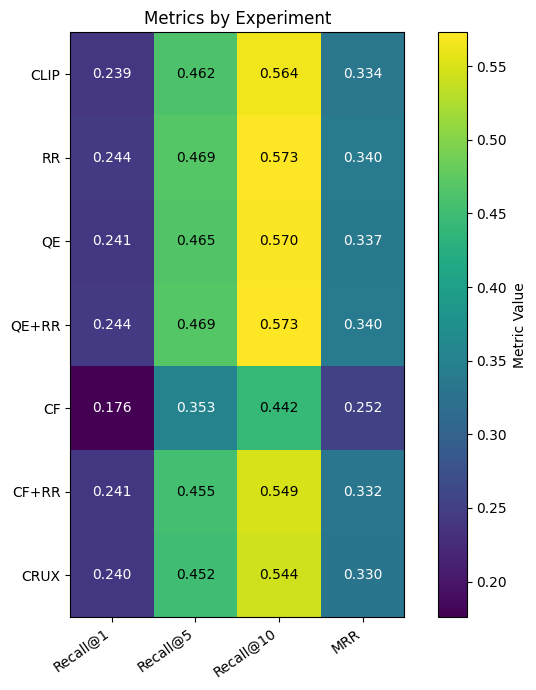

In [7]:
label_map = {
    "CLIP Retrieval": "CLIP",
    "CLIP Retrieval | CLIP Reranker": "RR",
    "CLIP Retrieval | LLM-QE": "QE",
    "CLIP Retrieval | LLM-QE | CLIP Reranker": "QE+RR",
    "CLIP Retrieval | BLIP2 Captions Fusion": "CF",
    "CLIP Retrieval | BLIP2 Captions Fusion | CLIP Reranking": "CF+RR",
    "CLIP Retrieval | LLM-QE | BLIP2 Captions Fusion | CLIP Reranking": "CRUX"
}

# Replace dataframe index directly
df_plot = df_metrics.copy()
df_plot.index = [label_map.get(i, i) for i in df_plot.index]

fig, ax = plt.subplots(figsize=(7, 7))  # square figure


vals = df_plot.to_numpy(dtype=float)

im = ax.imshow(
    vals,
    aspect="equal",   # force square cells
    cmap="viridis",
    vmin=vals.min(),
    vmax=vals.max()
)

ax.set_xticks(np.arange(len(df_plot.columns)))
ax.set_xticklabels(df_plot.columns, rotation=35, ha="right")

ax.set_yticks(np.arange(len(df_plot.index)))
ax.set_yticklabels(df_plot.index)

for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        v = vals[i, j]
        ax.text(
            j,
            i,
            f"{v:.3f}",
            ha="center",
            va="center",
            color="white" if v < (vals.min() + vals.max()) / 2 else "black"
        )

ax.set_title("Metrics by Experiment")
fig.colorbar(im, ax=ax, label="Metric Value")

plt.tight_layout()
plt.show()

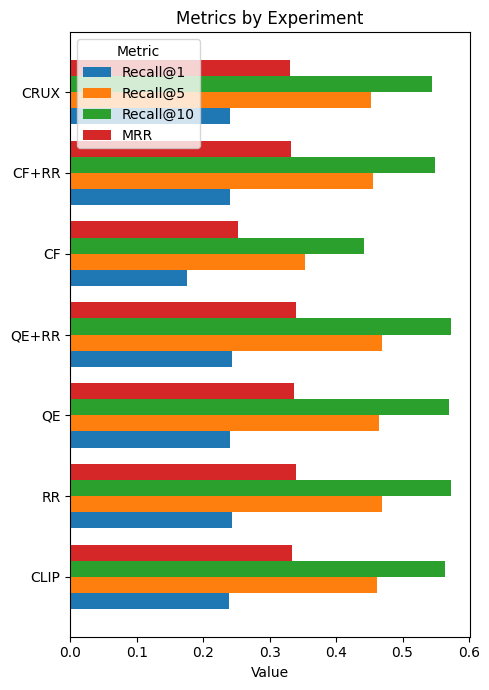

In [14]:
label_map = {
    "CLIP Retrieval": "CLIP",
    "CLIP Retrieval | CLIP Reranker": "RR",
    "CLIP Retrieval | LLM-QE": "QE",
    "CLIP Retrieval | LLM-QE | CLIP Reranker": "QE+RR",
    "CLIP Retrieval | BLIP2 Captions Fusion": "CF",
    "CLIP Retrieval | BLIP2 Captions Fusion | CLIP Reranking": "CF+RR",
    "CLIP Retrieval | LLM-QE | BLIP2 Captions Fusion | CLIP Reranking": "CRUX"
}

# Apply mapping
names = [label_map.get(i, i) for i in df_metrics.index.tolist()]

metrics_list = df_metrics.columns.tolist()

y = np.arange(len(names))
height = 0.8 / len(metrics_list)

fig, ax = plt.subplots(figsize=(5, 7))

for k, col in enumerate(metrics_list):
    ax.barh(
        y + (k - (len(metrics_list) - 1) / 2) * height,
        df_metrics[col].to_numpy(),
        height,
        label=col,
    )

ax.set_yticks(y)
ax.set_yticklabels(names)

ax.set_xlabel("Value")
ax.set_title("Metrics by Experiment")

ax.legend(title="Metric", loc="upper left")

ax.set_xlim(0, None)

plt.tight_layout()
plt.show()

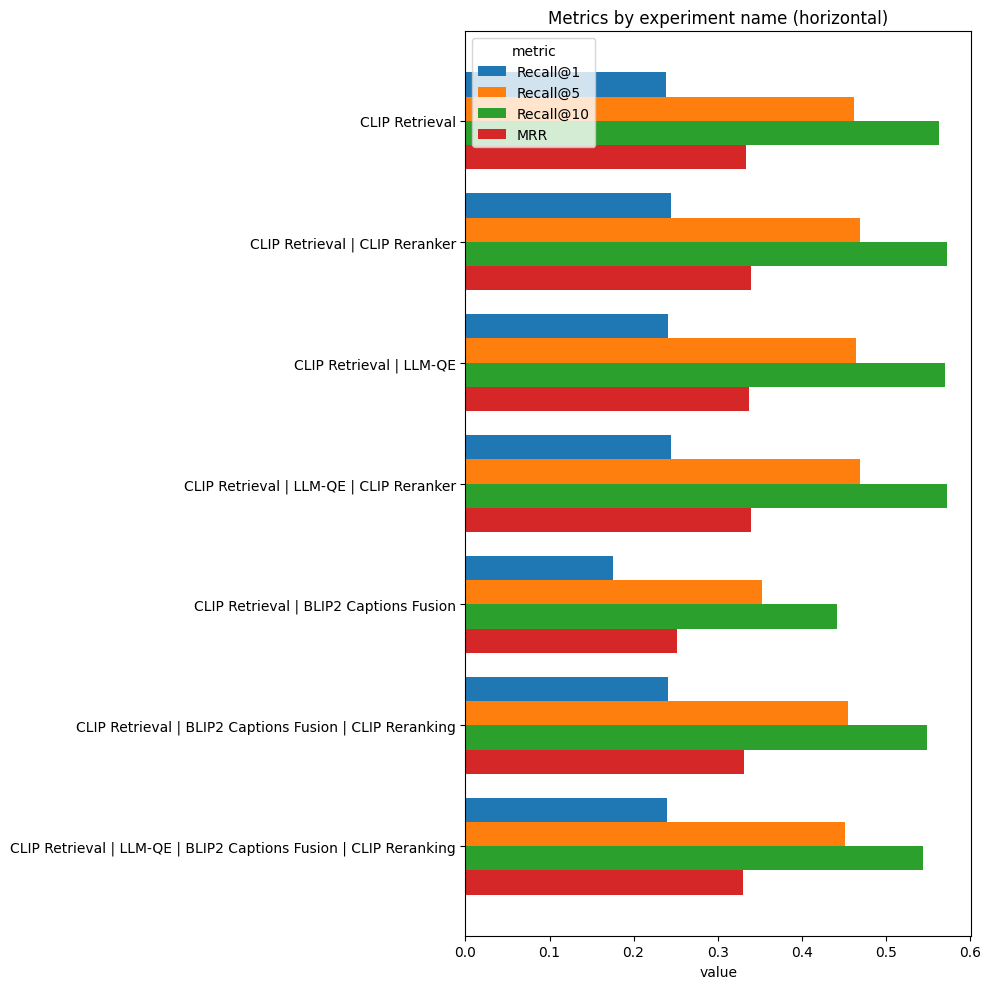

In [4]:
names = df_metrics.index.tolist()
metrics_list = df_metrics.columns.tolist()
y = np.arange(len(names))
width = 0.8 / len(metrics_list)
fig, ax = plt.subplots(figsize=(10, max(10, 0.5 * len(names))))
for k, col in enumerate(metrics_list):
    ax.barh(y + (k - (len(metrics_list) - 1) / 2) * width, df_metrics[col], width, label=col)
ax.set_yticks(y)
ax.set_yticklabels(names)
ax.set_xlabel("value")
ax.set_title("Metrics by experiment name (horizontal)")
ax.legend(title="metric", loc="upper left")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

/var/folders/g2/9_y7bfxs4l7clq4gyjjn2_5m0000gn/T/ipykernel_96780/2246563904.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


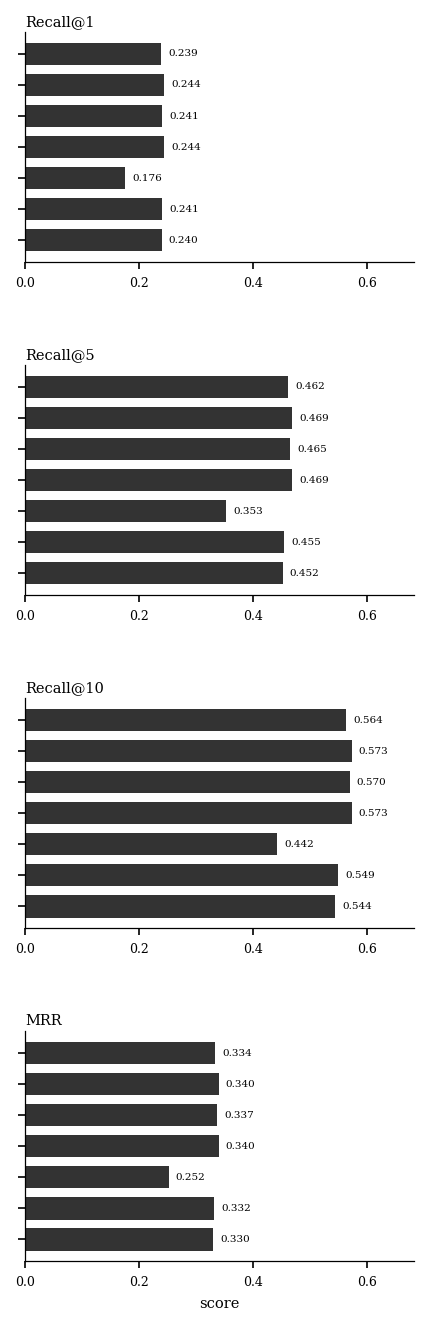

In [19]:
import textwrap

# ~IEEE/ACM single-column width (inches); adjust to your template
SINGLE_COL_W_IN = 3.35

pub_rc = {
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 5.5,
    "axes.linewidth": 0.6,
    "lines.linewidth": 0.8,
}

names = df_metrics.index.tolist()
metrics_list = list(df_metrics.columns)
y = np.arange(len(names))
# Wrap labels so they fit a narrow column (lower `width` = narrower figure-friendly)
wrapped = ["\n".join(textwrap.wrap(str(n), width=18)) for n in names]

with plt.rc_context(pub_rc):
    nrows = len(metrics_list)
    fig_h = max(2.8, 0.38 * len(names) * nrows)
    fig, axes = plt.subplots(
        nrows,
        1,
        sharey=True,
        figsize=(SINGLE_COL_W_IN, fig_h),
        gridspec_kw={"hspace": 0.45},
    )
    if nrows == 1:
        axes = [axes]
    xmax = float(df_metrics.to_numpy().max()) * 1.14 + 0.03
    xpad = xmax * 0.018
    for ax, col in zip(axes, metrics_list):
        vals = df_metrics[col].to_numpy()
        ax.barh(y, vals, height=0.72, color=".2")
        for yi, v in zip(y, vals):
            ax.text(v + xpad, yi, f"{v:.3f}", va="center", ha="left", fontsize=5)
        ax.set_title(col, loc="left", pad=3)
        ax.set_xlim(0, xmax)
        ax.tick_params(axis="y", labelleft=False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
    axes[0].set_yticks(y)
    axes[0].set_yticklabels(wrapped)
    axes[0].invert_yaxis()
    axes[-1].set_xlabel("score")
    fig.align_xlabels(axes)

plt.tight_layout()
plt.show()

# Uncomment to export for LaTeX (vector):
# fig.savefig("metrics_single_column.pdf", bbox_inches="tight", pad_inches=0.02)

                                         System  Order    R@1    R@5   R@10  \
0                                          CLIP      1  0.239  0.462  0.564   
1                              CLIP + Re-ranker      2  0.244  0.469  0.573   
2                                 CLIP + LLM-QE      3  0.241  0.465  0.570   
3                     CLIP + LLM-QE + Re-ranker      4  0.244  0.469  0.573   
4                         CLIP + Caption Fusion      5  0.176  0.353  0.442   
5             CLIP + Caption Fusion + Re-ranker      6  0.241  0.455  0.549   
6  Hybrid (LLM-QE + Caption Fusion + Re-ranker)      7  0.240  0.452  0.544   

     MRR  
0  0.334  
1  0.340  
2  0.337  
3  0.340  
4  0.252  
5  0.332  
6  0.330  


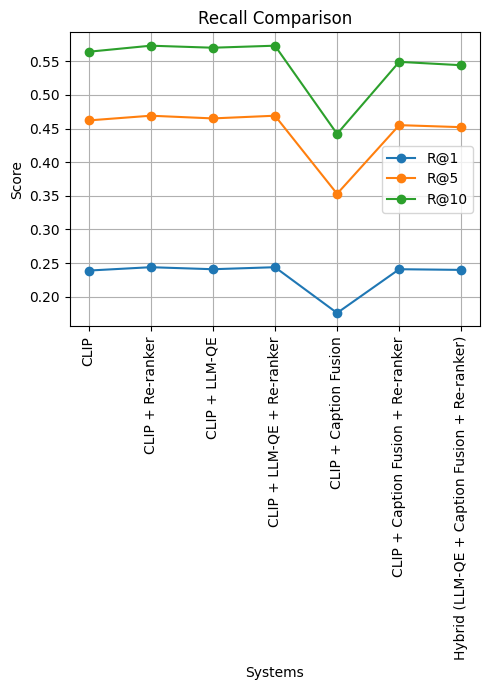

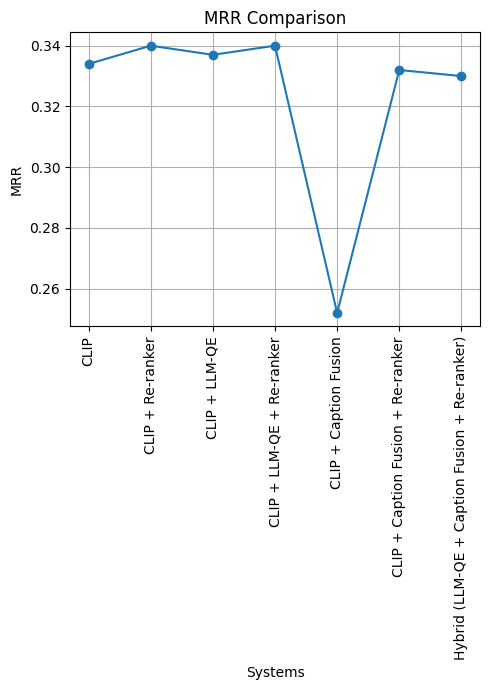

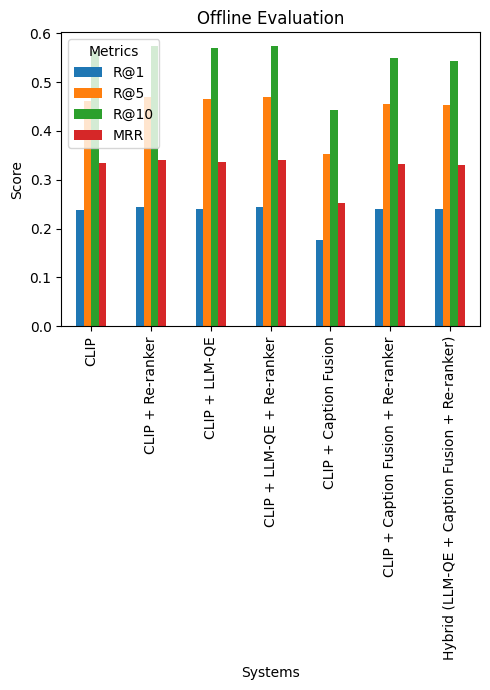

In [15]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load JSON
# -----------------------------
with open("../logs/logs_paper_aligned.json", "r") as f:
    data = json.load(f)

# -----------------------------
# Label Mapping
# -----------------------------
label_map = {
    "CLIP Retrieval": "CLIP",
    "CLIP Retrieval | CLIP Reranker": "RR",
    "CLIP Retrieval | LLM-QE": "QE",
    "CLIP Retrieval | LLM-QE | CLIP Reranker": "QE+RR",
    "CLIP Retrieval | BLIP2 Captions Fusion": "CF",
    "CLIP Retrieval | BLIP2 Captions Fusion | CLIP Reranking": "CF+RR",
    "CLIP Retrieval | LLM-QE | BLIP2 Captions Fusion | CLIP Reranking": "CRUX"
}

# -----------------------------
# Convert to DataFrame
# -----------------------------
rows = []

for exp in data["experiments"]:
    rows.append({
        "System": label_map.get(exp["paper_experiment_name"],
                                exp["paper_experiment_name"]),
        "Order": exp["plot_order"],
        "R@1": exp["metrics"]["Recall@1"],
        "R@5": exp["metrics"]["Recall@5"],
        "R@10": exp["metrics"]["Recall@10"],
        "MRR": exp["metrics"]["MRR"]
    })

df = pd.DataFrame(rows)

# Sort properly
df = df.sort_values("Order")

print(df)

# -----------------------------
# Plot 1: Recall Comparison
# -----------------------------
plt.figure(figsize=(5, 7))

plt.plot(df["System"], df["R@1"], marker='o', label='R@1')
plt.plot(df["System"], df["R@5"], marker='o', label='R@5')
plt.plot(df["System"], df["R@10"], marker='o', label='R@10')

plt.xticks(rotation=90)
plt.ylabel("Score")
plt.xlabel("Systems")
plt.title("Recall Comparison")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("recall_comparison.png", dpi=300)
plt.show()

# -----------------------------
# Plot 2: MRR Comparison
# -----------------------------
plt.figure(figsize=(5, 7))

plt.plot(df["System"], df["MRR"], marker='o')

plt.xticks(rotation=90)
plt.ylabel("MRR")
plt.xlabel("Systems")
plt.title("MRR Comparison")
plt.grid(True)

plt.tight_layout()
plt.savefig("mrr_comparison.png", dpi=300)
plt.show()

# -----------------------------
# Plot 3: Vertical Paper-style Bar Plot
# -----------------------------
metrics = ["R@1", "R@5", "R@10", "MRR"]

ax = df.set_index("System")[metrics].plot(
    kind="bar",
    figsize=(5, 7)
)

plt.ylabel("Score")
plt.xlabel("Systems")
plt.title("Offline Evaluation")
plt.xticks(rotation=90)
plt.legend(title="Metrics", loc="upper left")

plt.tight_layout()

plt.savefig("paper_barplot.png", dpi=300)
plt.show()

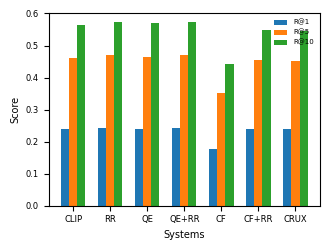

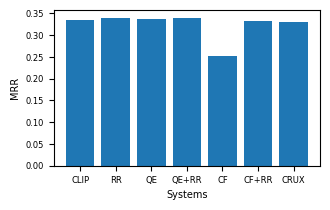

In [16]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Load JSON
# -----------------------------
with open("../logs/logs_paper_aligned.json", "r") as f:
    data = json.load(f)

# -----------------------------
# Build DataFrame
# -----------------------------
rows = []

label_map = {
    "CLIP Retrieval": "CLIP",
    "CLIP + Re-ranker": "RR",
    "CLIP + LLM-QE": "QE",
    "CLIP + LLM-QE + Re-ranker": "QE+RR",
    "CLIP + Caption Fusion": "CF",
    "CLIP + Caption Fusion + Re-ranker": "CF+RR",
    "Hybrid (LLM-QE + Caption Fusion + Re-ranker)": "CRUX"
}

for exp in data["experiments"]:
    rows.append({
        "System": label_map[exp["paper_experiment_name"]],
        "Order": exp["plot_order"],
        "R@1": exp["metrics"]["Recall@1"],
        "R@5": exp["metrics"]["Recall@5"],
        "R@10": exp["metrics"]["Recall@10"],
        "MRR": exp["metrics"]["MRR"]
    })

df = pd.DataFrame(rows).sort_values("Order")

# -----------------------------
# Figure 1:
# Vertical Grouped Bar Chart
# Recall Metrics
# -----------------------------
x = np.arange(len(df))
width = 0.22

fig, ax = plt.subplots(figsize=(3.4, 2.6))

ax.bar(x - width, df["R@1"], width, label="R@1")
ax.bar(x,         df["R@5"], width, label="R@5")
ax.bar(x + width, df["R@10"], width, label="R@10")

ax.set_ylabel("Score", fontsize=7)
ax.set_xlabel("Systems", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(df["System"], fontsize=6)

ax.tick_params(axis='y', labelsize=6)

ax.legend(fontsize=5, frameon=False)

plt.tight_layout()

plt.savefig("recall_vertical_bar.pdf", bbox_inches='tight')
plt.savefig("recall_vertical_bar.png", dpi=300, bbox_inches='tight')

plt.show()

# -----------------------------
# Figure 2:
# Vertical Bar Chart for MRR
# -----------------------------
fig, ax = plt.subplots(figsize=(3.4, 2.2))

ax.bar(df["System"], df["MRR"])

ax.set_ylabel("MRR", fontsize=7)
ax.set_xlabel("Systems", fontsize=7)

ax.tick_params(axis='x', labelsize=6)
ax.tick_params(axis='y', labelsize=6)

plt.tight_layout()

plt.savefig("mrr_vertical_bar.pdf", bbox_inches='tight')
plt.savefig("mrr_vertical_bar.png", dpi=300, bbox_inches='tight')

plt.show()